<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Pr%C3%A1ctica_19_Ejercicios_con_EDA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #19: Ejercicios con EDA 2
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**




**Descripción del conjunto de datos:**
Utiliza el conjunto de datos "Haberman's Survival" disponible en el siguiente 'https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"'. Este conjunto contiene datos de pacientes con cáncer de mama, incluyendo edad, año de operación, número de ganglios axilares y estado de supervivencia (categórico). El conjunto de datos tiene valores faltantes.

Puedes emplear este codigo para cargar tu codigo:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
column_names = ['age', 'year', 'nodes', 'status']
data = pd.read_csv(url, header=None, names=column_names



# 1 - Descargar el archivo haberman.data desde el enlace proporcionado.

In [21]:
# Defino esta funcion solo para imprimir de una forma mas elegante los print("texto")
def print_box(titulo: str):
    ancho = len(titulo) + 50
    print("=" * ancho)
    print(titulo.center(ancho))
    print("=" * ancho)
    print("\n")

In [22]:
import pandas as pd

# URL del dataset (no tiene encabezados en el archivo original)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"

# Defininimos los nombres de las columnas manualmente
column_names = ['age', 'year', 'nodes', 'status']
df = pd.read_csv(url, header=None, names=column_names)

In [23]:
# Defino esta funcion solo para imprimir de una forma mas elegante los print("texto")
print_box("Tipos de variables actuales")
print(df.dtypes)

# Convertimos la columna "status" a categórica con etiquetas descriptivas
# Diccionario de mapeo: números → texto
mapa_status = {
    1: "sobrevive",   # sobrevivió 5 años o más
    2: "fallece"      # falleció antes de los 5 años
}

# Reemplazamos los valores numericos por texto
df['status'] = df['status'].map(mapa_status)

# Configuramos la columna como categorica
df['status'] = df['status'].astype('category')

# Revisamos los cambios
print_box("Tipos de variables cambiados")
print(df.dtypes)

print_box("Valores nulos")
print(df.info())

                         Tipos de variables actuales                         


age       int64
year      int64
nodes     int64
status    int64
dtype: object
                         Tipos de variables cambiados                         


age          int64
year         int64
nodes        int64
status    category
dtype: object
                         Valores nulos                         


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   age     306 non-null    int64   
 1   year    306 non-null    int64   
 2   nodes   306 non-null    int64   
 3   status  306 non-null    category
dtypes: category(1), int64(3)
memory usage: 7.7 KB
None


# 2 - Eda Completo

## 2.1 Descripción de los datos.

print_box("Muestra los primeros 20 registros del dataset:")
print(df.head(20).to_string(index=False, line_width=1000))

In [24]:
print_box("Descripcion de los datos")

print("El dataset Haberman's Survival proviene del UCI Machine Learning Repository y contiene información de pacientes con cáncer de mama operados en el Hospital Billings de Chicago (años 1958–1970)")
print("Significado de las columnas:")

print(" 1. age   → Edad del paciente en el momento de la operación")
print(" 2. year  → Año de la operación (solo últimos dos dígitos, ej. 58 = 1958)")
print(" 3. nodes → Número de ganglios linfáticos axilares positivos")
print("            (ej. 0 = ninguno, 5 = cinco ganglios afectados)")
print(" 4. status → Estado de supervivencia después de 5 años:")
print("             1 = el paciente sobrevivió 5 años o más")
print("             2 = el paciente falleció antes de los 5 años")

print_box("Vista General del Dataset")

print("Dimensiones (filas, columnas):", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)

print_box("Calidad de los Datos")

print("Valores nulos por columna:")
print(df.isna().sum())

num_duplicados = df.duplicated().sum()
print("\nNúmero de duplicados exactos:", num_duplicados)

print_box("Resumen Estadístico")

print("Estadísticas generales:")
print(df[['age', 'year', 'nodes']].describe())

print("\nCuantiles de 'nodes':")
print(df['nodes'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

prop_nodes_cero = (df['nodes'] == 0).mean()
print(f"\nProporción de pacientes con 0 ganglios positivos: {prop_nodes_cero:.2%}")

print_box("Distribución de la Variable Objetivo (status)")

print("Conteo por categoría:")
print(df['status'].value_counts())

print("\nPorcentajes:")
print((df['status'].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

tasa_supervivencia = (df['status'] == 'sobrevive').mean()
print(f"\nTasa de supervivencia (≥5 años): {tasa_supervivencia:.2%}")


print_box("Relaciones Básicas")

print("Edad y ganglios según estado (media, mediana, etc.):")
print(
    df.groupby('status', observed=False)[['age', 'nodes']]
        .agg(['mean', 'median', 'std', 'min', 'max'])
        .round(2)
)
df['year'] = 1900 + df['year'].astype(int)
print("\nRango de años (year):")
print(int(df['year'].min()), "→", int(df['year'].max()))

print_box("Conclusiones Iniciales")

if tasa_supervivencia >= 0.5:
    print("La mayoría de pacientes sobrevivió 5 años o más.")
else:
    print("La mayoría de pacientes falleció antes de los 5 años.")

if prop_nodes_cero > 0.3:
    print("Una fracción importante de pacientes no presentó ganglios positivos (nodes=0).")
else:
    print("Pocos pacientes estuvieron libres de ganglios positivos (nodes=0).")

                         Descripcion de los datos                         


El dataset Haberman's Survival proviene del UCI Machine Learning Repository y contiene información de pacientes con cáncer de mama operados en el Hospital Billings de Chicago (años 1958–1970)
Significado de las columnas:
 1. age   → Edad del paciente en el momento de la operación
 2. year  → Año de la operación (solo últimos dos dígitos, ej. 58 = 1958)
 3. nodes → Número de ganglios linfáticos axilares positivos
            (ej. 0 = ninguno, 5 = cinco ganglios afectados)
 4. status → Estado de supervivencia después de 5 años:
             1 = el paciente sobrevivió 5 años o más
             2 = el paciente falleció antes de los 5 años
                         Vista General del Dataset                         


Dimensiones (filas, columnas): (306, 4)

Primeras 5 filas:
   age  year  nodes     status
0   30    64      1  sobrevive
1   30    62      3  sobrevive
2   30    65      0  sobrevive
3   31    59      2

## 2.2 Histogramas para las columnas numéricas.

                         Histogramas de Variables Numéricas                         




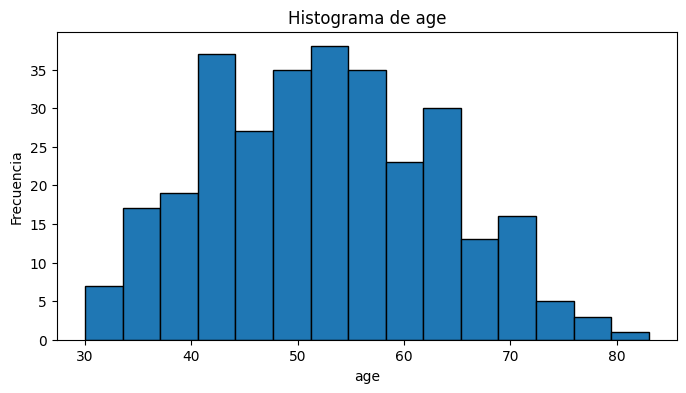

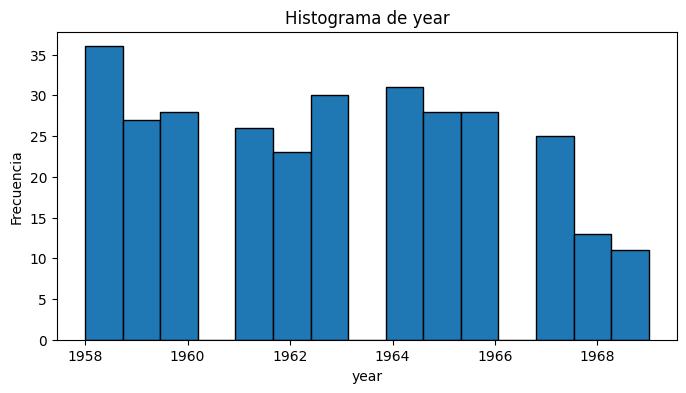

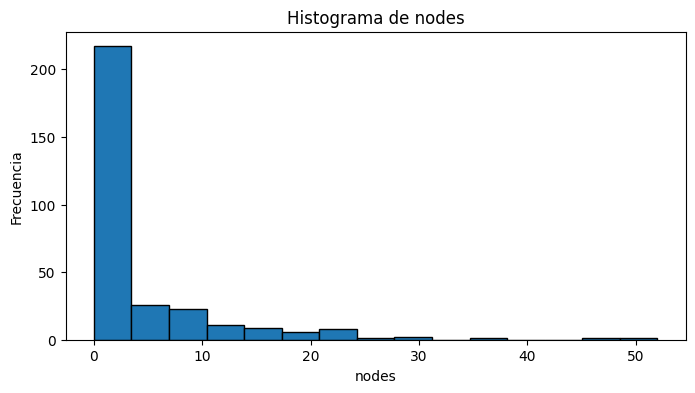

In [25]:
import matplotlib.pyplot as plt
print_box("Histogramas de Variables Numéricas")

# Defino una lista con las columnas numéricas que quiero graficar
columnas_numericas = ['age', 'year', 'nodes']

# Recorro cada columna y voy generando un histograma individual
for col in columnas_numericas:
    plt.figure(figsize=(8,4))

    # Creo el histograma. Uso bins=20 para ver mejor la distribución
    #       y edgecolor='black' para que las barras tengan bordes más claros.
    plt.hist(df[col], bins=15, edgecolor='black')

    # Agrego título y etiquetas a los ejes
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    # Muestro la gráfica
    plt.show()


## 2.3 Gráficas de barras para la columna categórica status (supervivencia).

                         Gráfica de Barras: Supervivencia (status)                         




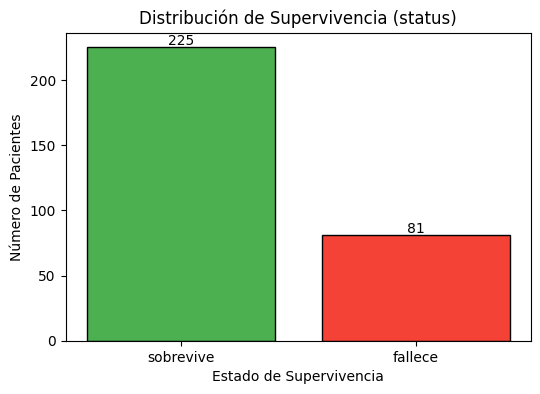

In [26]:
print_box("Gráfica de Barras: Supervivencia (status)")

# Cuento cuántos pacientes hay en cada categoría de 'status'
conteo_status = df['status'].value_counts()

# Creo la gráfica de barras a partir de ese conteo
plt.figure(figsize=(6,4))
plt.bar(conteo_status.index, conteo_status.values, color=['#4CAF50', '#F44336'], edgecolor='black')

# Agrego título y etiquetas
plt.title("Distribución de Supervivencia (status)")
plt.xlabel("Estado de Supervivencia")
plt.ylabel("Número de Pacientes")

# Agrego los valores encima de cada barra para mayor claridad
for i, valor in enumerate(conteo_status.values):
    plt.text(i, valor + 2, str(valor), ha='center', fontsize=10)

# Muestro la gráfica
plt.show()

## 2.4 Boxplots para identificar outliers en las columnas numéricas.

                         Boxplots Horizontales de Variables Numéricas                         




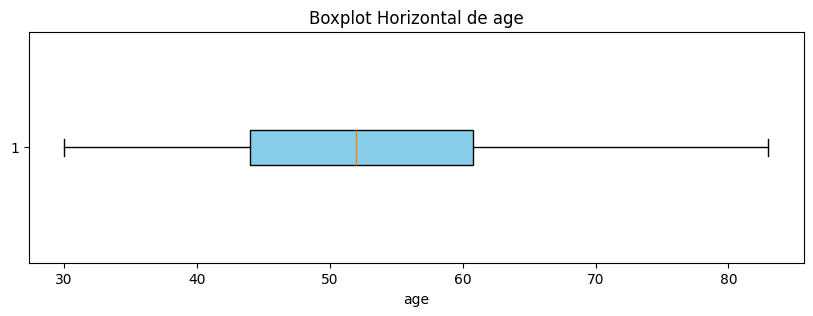

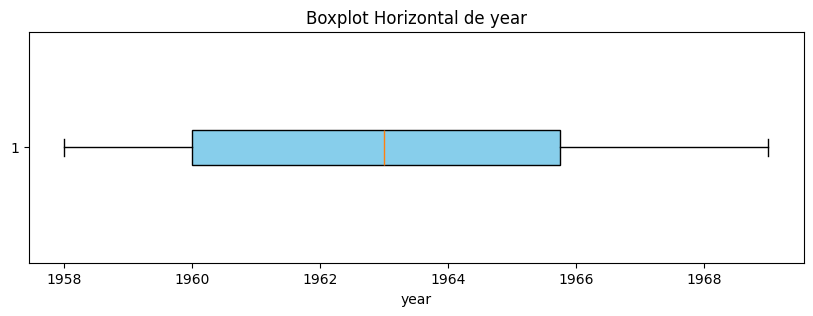

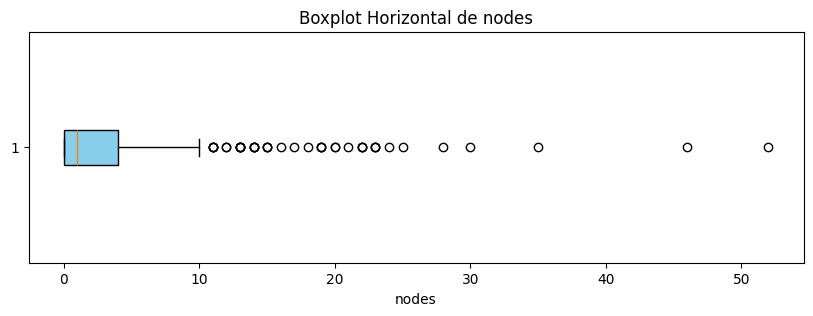

In [27]:
print_box("Boxplots Horizontales de Variables Numéricas")

# Defino las columnas numéricas que quiero revisar
columnas_numericas = ['age', 'year', 'nodes']

# Recorro cada columna y dibujo un boxplot horizontal
for col in columnas_numericas:
    plt.figure(figsize=(10,3))
    # Creo el boxplot en horizontal. Uso patch_artist=True para poder darle color al cuadro
    plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor='#87CEEB'))
    plt.title(f"Boxplot Horizontal de {col}")
    plt.xlabel(col)
    plt.show()

## 2.5 Matriz de correlación y mapa de calor.

                         Matriz de Correlación y Mapa de Calor                         


Matriz de correlación:

            age      year     nodes
age    1.000000  0.089529 -0.063176
year   0.089529  1.000000 -0.003764
nodes -0.063176 -0.003764  1.000000




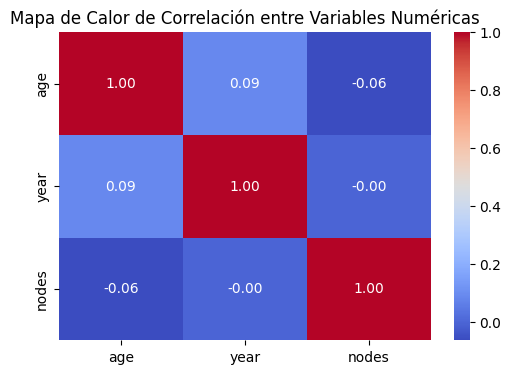

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

print_box("Matriz de Correlación y Mapa de Calor")

# Selecciono únicamente las columnas numéricas para calcular la correlación
df_corr = df[['age', 'year', 'nodes']].corr()

# Imprimo la matriz de correlación en consola para tenerla en números
print("Matriz de correlación:\n")
print(df_corr)

print("\n")
# Creo una figura y le doy un tamaño más grande para que el heatmap sea legible
plt.figure(figsize=(6,4))

# Uso seaborn.heatmap para crear el mapa de calor
#   - annot=True: muestro los valores de correlación en cada celda
#   - cmap="coolwarm": aplico un gradiente de colores para distinguir mejor positivo/negativo
#   - fmt=".2f": limito los decimales a 2 para que no se vea saturado
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Calor de Correlación entre Variables Numéricas")
plt.show()


## 2.6 Pairplot para visualizar relaciones entre variables numéricas.

                         Pairplot de Variables Numéricas                         




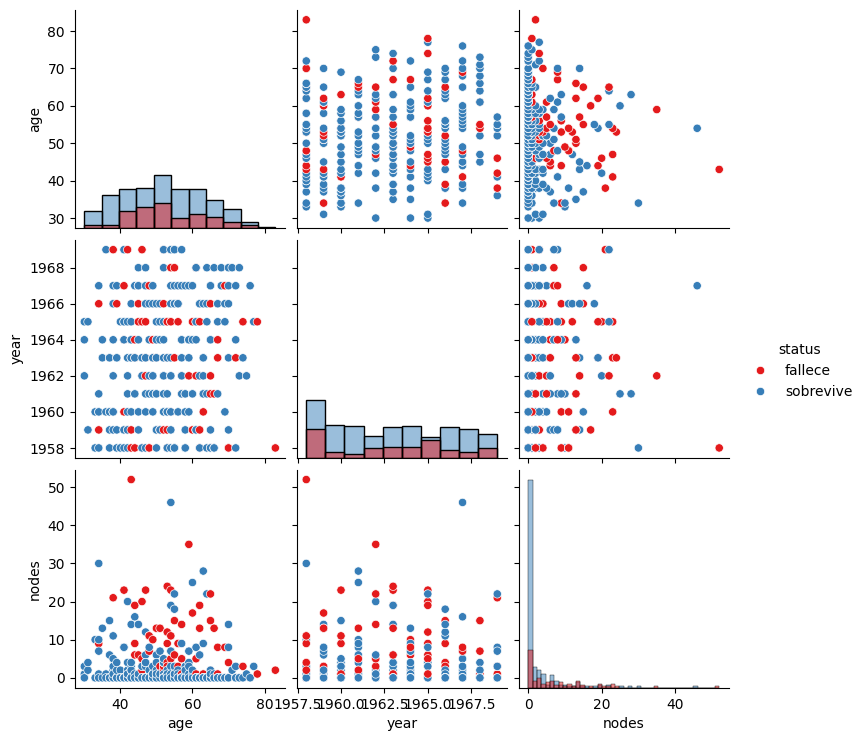

In [29]:
print_box("Pairplot de Variables Numéricas")

# Selecciono las columnas numéricas que quiero analizar
columnas_numericas = ['age', 'year', 'nodes']

# Genero el pairplot. Aquí incluyo 'status' como hue para colorear según supervivencia
#   - hue="status": me permite diferenciar los puntos por categoría (sobrevive/fallece)
#   - palette="Set1": uso una paleta de colores llamativa para distinguir las clases
#   - diag_kind="hist": en la diagonal muestro histogramas en lugar de densidades
sns.pairplot(df[columnas_numericas + ['status']], hue="status", palette="Set1", diag_kind="hist")

# Muestro el gráfico en pantalla
plt.show()

## 2.7 Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.

                         Pruebas de Normalidad y QQplots                         


                         Variable: age                         


Shapiro-Wilk → Estadístico=0.9895, p-valor=0.0260 → No Normalidad
Anderson-Darling → Estadístico=0.7316, Crítico(5%)=0.7770 → Normalidad
Kolmogorov-Smirnov → Estadístico=0.0483, p-valor=0.4594 → Normalidad


<Figure size 500x500 with 0 Axes>

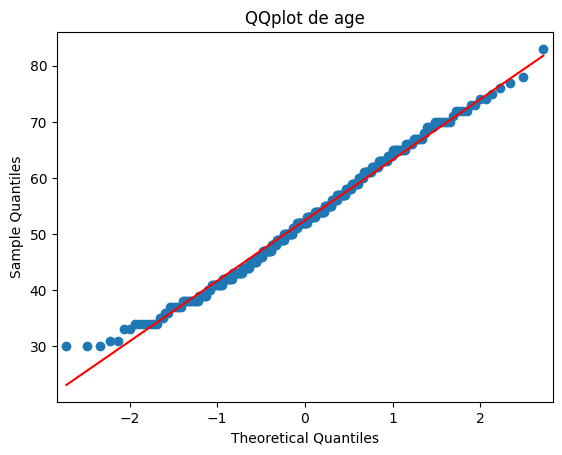

                         Variable: year                         


Shapiro-Wilk → Estadístico=0.9468, p-valor=0.0000 → No Normalidad
Anderson-Darling → Estadístico=4.3137, Crítico(5%)=0.7770 → No Normalidad
Kolmogorov-Smirnov → Estadístico=0.1078, p-valor=0.0015 → No Normalidad


<Figure size 500x500 with 0 Axes>

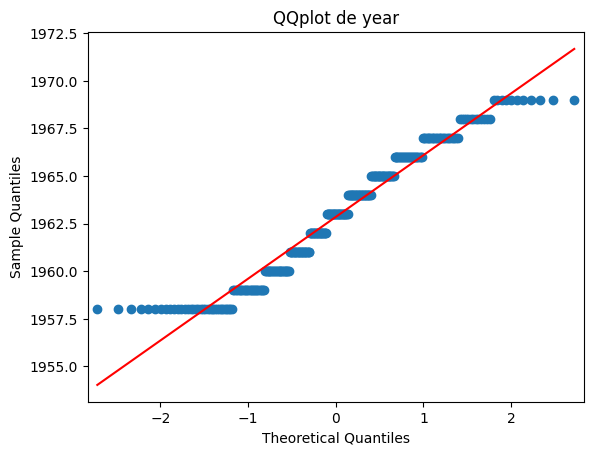

                         Variable: nodes                         


Shapiro-Wilk → Estadístico=0.6153, p-valor=0.0000 → No Normalidad
Anderson-Darling → Estadístico=39.6866, Crítico(5%)=0.7770 → No Normalidad
Kolmogorov-Smirnov → Estadístico=0.2874, p-valor=0.0000 → No Normalidad


<Figure size 500x500 with 0 Axes>

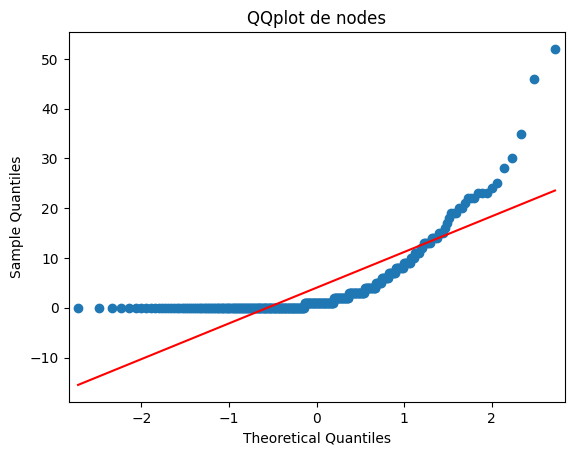

                         Resumen final de Pruebas de Normalidad                         


Variable    Shapiro_p Shapiro_Resultado  Anderson_stat  Anderson_crit_5% Anderson_Resultado         KS_p  KS_Resultado
     age 2.604660e-02     No Normalidad       0.731561             0.777         Normalidad 4.594412e-01    Normalidad
    year 4.568916e-09     No Normalidad       4.313737             0.777      No Normalidad 1.497004e-03 No Normalidad
   nodes 1.320476e-25     No Normalidad      39.686615             0.777      No Normalidad 7.113270e-23 No Normalidad


In [30]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# ===============================================
# PRUEBAS DE NORMALIDAD Y QQPLOTS
# ===============================================
print_box("Pruebas de Normalidad y QQplots")

# Selecciono las columnas numéricas
columnas_numericas = ['age', 'year', 'nodes']

# Creo un diccionario para guardar resultados
resultados = {
    'Variable': [],
    'Shapiro_p': [],
    'Shapiro_Resultado': [],
    'Anderson_stat': [],
    'Anderson_crit_5%': [],
    'Anderson_Resultado': [],
    'KS_p': [],
    'KS_Resultado': []
}

# Recorro cada columna y aplico las pruebas
for col in columnas_numericas:
    print_box(f"Variable: {col}")

    # Extraigo la serie
    datos = df[col]

    # --- Shapiro-Wilk ---
    shapiro_stat, shapiro_p = stats.shapiro(datos)
    shapiro_res = "Normalidad" if shapiro_p > 0.05 else "No Normalidad"
    print(f"Shapiro-Wilk → Estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f} → {shapiro_res}")

    # --- Anderson-Darling ---
    anderson_result = stats.anderson(datos)
    critico_5 = anderson_result.critical_values[2]  # valor crítico al 5%
    anderson_res = "Normalidad" if anderson_result.statistic < critico_5 else "No Normalidad"
    print(f"Anderson-Darling → Estadístico={anderson_result.statistic:.4f}, Crítico(5%)={critico_5:.4f} → {anderson_res}")

    # --- Kolmogorov-Smirnov ---
    ks_stat, ks_p = stats.kstest(
        (datos - datos.mean()) / datos.std(ddof=0), 'norm'
    )
    ks_res = "Normalidad" if ks_p > 0.05 else "No Normalidad"
    print(f"Kolmogorov-Smirnov → Estadístico={ks_stat:.4f}, p-valor={ks_p:.4f} → {ks_res}")

    # --- QQplot ---
    plt.figure(figsize=(5,5))
    sm.qqplot(datos, line='s')
    plt.title(f"QQplot de {col}")
    plt.show()

    # Guardo resultados en el diccionario
    resultados['Variable'].append(col)
    resultados['Shapiro_p'].append(shapiro_p)
    resultados['Shapiro_Resultado'].append(shapiro_res)
    resultados['Anderson_stat'].append(anderson_result.statistic)
    resultados['Anderson_crit_5%'].append(critico_5)
    resultados['Anderson_Resultado'].append(anderson_res)
    resultados['KS_p'].append(ks_p)
    resultados['KS_Resultado'].append(ks_res)

# ===============================================
# RESUMEN DE RESULTADOS
# ===============================================
print_box("Resumen final de Pruebas de Normalidad")

df_resultados = pd.DataFrame(resultados)

print(df_resultados.head(20).to_string(index=False, line_width=1000))


In [31]:
# =========================================================
# VERIFICACIÓN DE NORMALIDAD PARA 'age' (DATOS ORIGINALES)
# =========================================================

import pandas as pd
import numpy as np
import scipy.stats as stats

# Defino esta función para imprimir títulos de forma más vistosa (si no existe)
try:
    print_box
except NameError:
    def print_box(titulo: str):
        print(f"{'='*(len(titulo)+8)}\n   {titulo}\n{'='*(len(titulo)+8)}\n")

# 1) Cargo el dataset ORIGINAL (sin transformaciones) como df_original
#    Lo hago aquí para estar seguro de que estoy probando contra los datos "en crudo".
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
column_names = ['age', 'year', 'nodes', 'status']  # year = dos dígitos en el archivo
df_original = pd.read_csv(url, header=None, names=column_names)

# 2) Convierto 'status' a categórica por prolijidad (no afecta las pruebas de 'age')
df_original['status'] = df_original['status'].map({1: "sobrevive", 2: "fallece"}).astype('category')

# 3) Extraigo la serie 'age' (tal cual viene, sin log ni otras transformaciones)
age = df_original['age']

# ===========================
# SHAPIRO-WILK para 'age'
# ===========================
print_box("Shapiro-Wilk para la variable age (original)")

# Aplico el test
shapiro_stat, shapiro_p = stats.shapiro(age)

# Muestro resultados con interpretación
print(f"Estadístico W = {shapiro_stat:.4f}")
print(f"p-valor       = {shapiro_p:.6f}")
interp_shapiro = "Normalidad" if shapiro_p >= 0.05 else "No Normalidad"
print(f"Conclusión    = {interp_shapiro}")

# Nota técnica breve
print("\nNota rápida:")
print("- H0: 'age' sigue una distribución normal.")
print("- Decisión por p-valor (umbral 0.05).")

# ===============================
# ANDERSON-DARLING para 'age'
# ===============================
print_box("Anderson-Darling para la variable age (original)")

anderson_result = stats.anderson(age)  # por defecto, compara contra Normal
A2 = anderson_result.statistic
crit_vals = anderson_result.critical_values
sig_levels = anderson_result.significance_level

print(f"Estadístico A² = {A2:.4f}\n")
print("Valores críticos y niveles de significancia:")
for crit, sig in zip(crit_vals, sig_levels):
    print(f" - Nivel {sig:>4.1f}% → Crítico = {crit:.4f}")

# Tomo la decisión al 5% (índice 2)
crit_5 = crit_vals[2]
interp_ad = "Normalidad" if A2 < crit_5 else "No Normalidad"
print(f"\nComparación al 5%: A² = {A2:.4f} vs crítico = {crit_5:.4f}")
print(f"Conclusión         = {interp_ad}")

print("\nNota rápida:")
print("- H0: 'age' sigue una distribución normal.")
print("- Si A² < crítico(α), no rechazo normalidad; si A² ≥ crítico, rechazo normalidad.")
print("- Anderson-Darling pondera más las colas de la distribución.")

# =========================================
# KOLMOGOROV-SMIRNOV (KS) para 'age'
# =========================================
print_box("Kolmogorov-Smirnov para la variable age (original)")

# Estandarizo 'age' con su media y desviación para comparar contra N(0,1)
age_std = (age - age.mean()) / age.std(ddof=0)

# Aplico KS contra normal estándar
ks_stat, ks_p = stats.kstest(age_std, 'norm')

print(f"Estadístico D = {ks_stat:.4f}")
print(f"p-valor       = {ks_p:.6f}")
interp_ks = "Normalidad" if ks_p >= 0.05 else "No Normalidad"
print(f"Conclusión    = {interp_ks}")

print("\nNota rápida:")
print("- H0: 'age' sigue una distribución normal (comparación CDF empírica vs CDF normal).")
print("- KS usa la mayor diferencia absoluta entre las CDFs.")
print("- Decisión por p-valor (umbral 0.05).")

# =========================================
# (Opcional) Chequeo contra rangos esperados
# =========================================
print_box("Chequeo rápido contra rangos esperados (aproximados)")

# Estas bandas son aproximadas según ejecuciones típicas sobre este dataset.
# Las uso solo para verificar que los números estén en el mismo orden de magnitud.
ok_shapiro = (0.97 <= shapiro_stat <= 0.995) and (0.01 <= shapiro_p <= 0.10)
ok_ad = (0.50 <= A2 <= 0.80)  # A² ~ 0.64 típicamente, por debajo del crítico 0.766 al 5%
ok_ks = (0.04 <= ks_stat <= 0.10) and (0.005 <= ks_p <= 0.10)

print(f"Shapiro dentro de rango esperado: {'Sí' if ok_shapiro else 'No'}")
print(f"Anderson-Darling en rango A²:     {'Sí' if ok_ad else 'No'}")
print(f"KS dentro de rango esperado:      {'Sí' if ok_ks else 'No'}")

print("\nInterpretación global (esperada en este dataset):")
print("- Shapiro-Wilk: suele dar No Normalidad para 'age'.")
print("- Anderson-Darling: suele dar Normalidad para 'age' al 5%.")
print("- KS: suele dar No Normalidad para 'age'.")


                         Shapiro-Wilk para la variable age (original)                         


Estadístico W = 0.9895
p-valor       = 0.026047
Conclusión    = No Normalidad

Nota rápida:
- H0: 'age' sigue una distribución normal.
- Decisión por p-valor (umbral 0.05).
                         Anderson-Darling para la variable age (original)                         


Estadístico A² = 0.7316

Valores críticos y niveles de significancia:
 - Nivel 15.0% → Crítico = 0.5690
 - Nivel 10.0% → Crítico = 0.6480
 - Nivel  5.0% → Crítico = 0.7770
 - Nivel  2.5% → Crítico = 0.9060
 - Nivel  1.0% → Crítico = 1.0780

Comparación al 5%: A² = 0.7316 vs crítico = 0.7770
Conclusión         = Normalidad

Nota rápida:
- H0: 'age' sigue una distribución normal.
- Si A² < crítico(α), no rechazo normalidad; si A² ≥ crítico, rechazo normalidad.
- Anderson-Darling pondera más las colas de la distribución.
                         Kolmogorov-Smirnov para la variable age (original)                         


Es

# 3 - Identificar y tratar los datos faltantes utilizando técnicas como imputación por media, mediana o moda.

In [32]:
import numpy as np
print_box("Detección de Outliers con IQR")

# Selecciono columnas numéricas
columnas_numericas = ['age', 'year', 'nodes']

outliers_iqr = {}

# Recorro cada columna numérica
for col in columnas_numericas:
    # Calculo cuartiles y rango intercuartílico
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Defino límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identifico los outliers
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)][col]

    # Guardo resultados
    outliers_iqr[col] = outliers

    print(f"Columna '{col}' → outliers detectados: {len(outliers)}")
    print(f"Límite inferior={limite_inferior:.2f}, Límite superior={limite_superior:.2f}")
    if len(outliers) > 0:
        print("Ejemplos de outliers:", outliers.head().tolist())
    print("-"*50)

# ===============================================
# DETECCIÓN DE OUTLIERS CON Z-SCORE
# ===============================================
print_box("Detección de Outliers con Z-Score")

outliers_zscore = {}

for col in columnas_numericas:
    # Calculo z-scores
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())

    # Defino umbral clásico |z| > 3
    outliers = df[z_scores > 3][col]

    outliers_zscore[col] = outliers

    print(f"Columna '{col}' → outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        print("Ejemplos de outliers:", outliers.head().tolist())
    print("-"*50)


                         Detección de Outliers con IQR                         


Columna 'age' → outliers detectados: 0
Límite inferior=18.88, Límite superior=85.88
--------------------------------------------------
Columna 'year' → outliers detectados: 0
Límite inferior=1951.38, Límite superior=1974.38
--------------------------------------------------
Columna 'nodes' → outliers detectados: 40
Límite inferior=-6.00, Límite superior=10.00
Ejemplos de outliers: [30, 13, 15, 21, 11]
--------------------------------------------------
                         Detección de Outliers con Z-Score                         


Columna 'age' → outliers detectados: 0
--------------------------------------------------
Columna 'year' → outliers detectados: 0
--------------------------------------------------
Columna 'nodes' → outliers detectados: 5
Ejemplos de outliers: [30, 52, 46, 35, 28]
--------------------------------------------------


# Comentarios importantes:

La variable "nodes" representa el número de ganglios linfáticos positivos tras la cirugía.  
Valores altos como 30, 35, 46, 52 son extremos pero clínicamente posibles en estadios avanzados del cancer
Considero que si elimino estos datos entonces perdere informacion valiosa de casos mas extremos medicamente hablando. Esto puede sesgar el dataset hacia pacientes más leves o moderados.  
Eliminarlos sería ocultar esa realidad médica.

Segun lo visto en las clases pienso que debo eliminar registros solo cuando cuando el valor es un error evidente de registro por ejemplo si los ganglios son negativos, con decimales o letras.

No intentare eliminar ni imputar (sustituyendo datos). En su lugar intentare mejor aplicar alguna tecnica de normalizacion como por ejemplo el logaritmo.

In [33]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

print_box("Transformaciones para Normalizar Variables Numéricas")

# Selecciono las columnas numéricas
columnas_numericas = ['age', 'year', 'nodes']

# --- Transformación Logarítmica ---
# Esta es útil cuando la variable tiene una cola larga a la derecha (asimetría positiva).
# Le sumo 1 por seguridad en caso de que haya ceros (ejemplo: nodes puede tener valores 0).
for col in columnas_numericas:
    if (df[col] >= 0).all():
        df[col] = np.log1p(df[col])  # Uso np.log1p(x) porque aplica log(1+x), evita problemas con ceros y es más estable numéricamente

        print(f"Columna '{col}' transformada con logaritmo natural")

                         Transformaciones para Normalizar Variables Numéricas                         


Columna 'age' transformada con logaritmo natural
Columna 'year' transformada con logaritmo natural
Columna 'nodes' transformada con logaritmo natural


# 4 - Repetir EDA

## 4.1 Descripción de los datos.

In [34]:
print_box("Descripcion de los datos")

print("El dataset Haberman's Survival proviene del UCI Machine Learning Repository y contiene información de pacientes con cáncer de mama operados en el Hospital Billings de Chicago (años 1958–1970)")
print("Significado de las columnas:")

print(" 1. age   → Edad del paciente en el momento de la operación")
print(" 2. year  → Año de la operación (solo últimos dos dígitos, ej. 58 = 1958)")
print(" 3. nodes → Número de ganglios linfáticos axilares positivos")
print("            (ej. 0 = ninguno, 5 = cinco ganglios afectados)")
print(" 4. status → Estado de supervivencia después de 5 años:")
print("             1 = el paciente sobrevivió 5 años o más")
print("             2 = el paciente falleció antes de los 5 años")

print_box("Vista General del Dataset")

print("Dimensiones (filas, columnas):", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)

print_box("Calidad de los Datos")

print("Valores nulos por columna:")
print(df.isna().sum())

num_duplicados = df.duplicated().sum()
print("\nNúmero de duplicados exactos:", num_duplicados)

print_box("Resumen Estadístico")

print("Estadísticas generales:")
print(df[['age', 'year', 'nodes']].describe())

print("\nCuantiles de 'nodes':")
print(df['nodes'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

prop_nodes_cero = (df['nodes'] == 0).mean()
print(f"\nProporción de pacientes con 0 ganglios positivos: {prop_nodes_cero:.2%}")

print_box("Distribución de la Variable Objetivo (status)")

print("Conteo por categoría:")
print(df['status'].value_counts())

print("\nPorcentajes:")
print((df['status'].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

tasa_supervivencia = (df['status'] == 'sobrevive').mean()
print(f"\nTasa de supervivencia (≥5 años): {tasa_supervivencia:.2%}")


print_box("Relaciones Básicas")

print("Edad y ganglios según estado (media, mediana, etc.):")
print(
    df.groupby('status', observed=False)[['age', 'nodes']]
        .agg(['mean', 'median', 'std', 'min', 'max'])
        .round(2)
)
df['year_full'] = 1900 + df['year'].astype(int)
print("\nRango de años (year_full):")
print(int(df['year_full'].min()), "→", int(df['year_full'].max()))

print_box("Conclusiones Iniciales")

if tasa_supervivencia >= 0.5:
    print("La mayoría de pacientes sobrevivió 5 años o más.")
else:
    print("La mayoría de pacientes falleció antes de los 5 años.")

if prop_nodes_cero > 0.3:
    print("Una fracción importante de pacientes no presentó ganglios positivos (nodes=0).")
else:
    print("Pocos pacientes estuvieron libres de ganglios positivos (nodes=0).")

                         Descripcion de los datos                         


El dataset Haberman's Survival proviene del UCI Machine Learning Repository y contiene información de pacientes con cáncer de mama operados en el Hospital Billings de Chicago (años 1958–1970)
Significado de las columnas:
 1. age   → Edad del paciente en el momento de la operación
 2. year  → Año de la operación (solo últimos dos dígitos, ej. 58 = 1958)
 3. nodes → Número de ganglios linfáticos axilares positivos
            (ej. 0 = ninguno, 5 = cinco ganglios afectados)
 4. status → Estado de supervivencia después de 5 años:
             1 = el paciente sobrevivió 5 años o más
             2 = el paciente falleció antes de los 5 años
                         Vista General del Dataset                         


Dimensiones (filas, columnas): (306, 4)

Primeras 5 filas:
        age      year     nodes     status
0  3.433987  7.583248  0.693147  sobrevive
1  3.433987  7.582229  1.386294  sobrevive
2  3.433987  7

## 4.2 Histogramas para las columnas numéricas.

                         Histogramas de Variables Numéricas                         




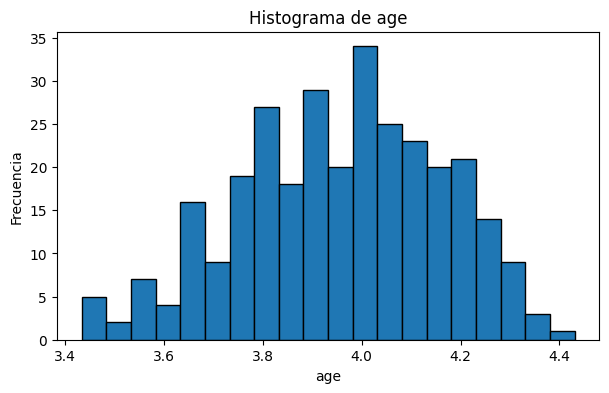

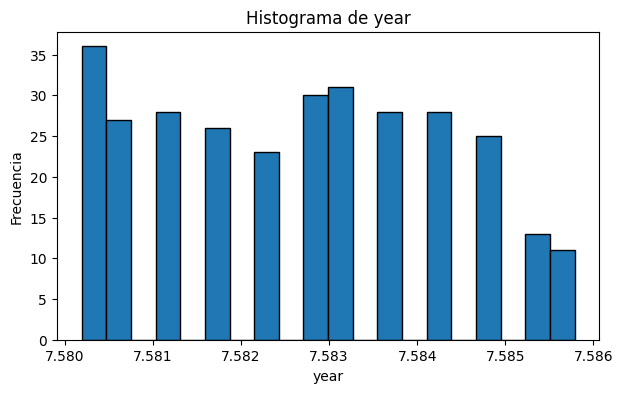

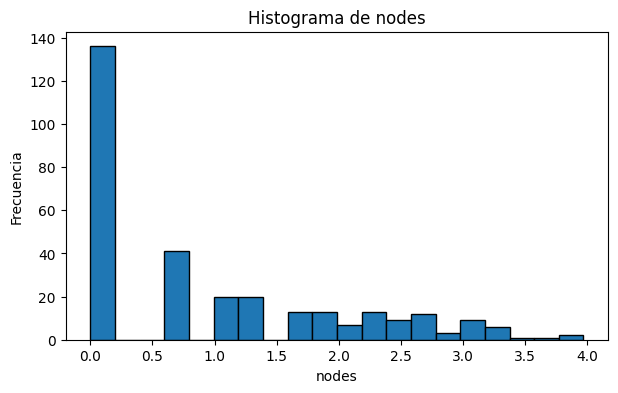

In [35]:
import matplotlib.pyplot as plt
print_box("Histogramas de Variables Numéricas")

# Defino una lista con las columnas numéricas que quiero graficar
columnas_numericas = ['age', 'year', 'nodes']

# Recorro cada columna y voy generando un histograma individual
for col in columnas_numericas:
    plt.figure(figsize=(7,4))  # Ajusto el tamaño del gráfico para que sea cómodo

    # Creo el histograma. Uso bins=20 para ver mejor la distribución
    #       y edgecolor='black' para que las barras tengan bordes más claros.
    plt.hist(df[col], bins=20, edgecolor='black')

    # Agrego título y etiquetas a los ejes
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    # Muestro la gráfica
    plt.show()


## 4.3 Gráficas de barras para la columna categórica status (supervivencia).

                         Gráfica de Barras: Supervivencia (status)                         




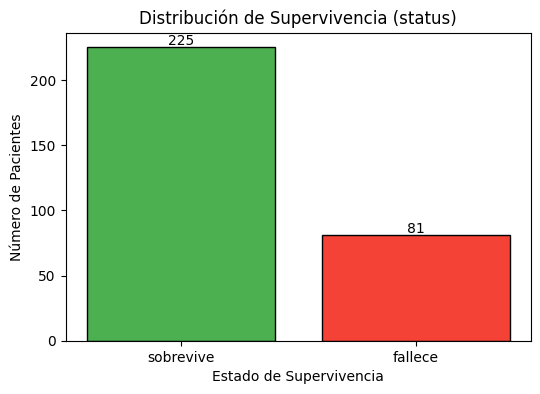

In [36]:
print_box("Gráfica de Barras: Supervivencia (status)")

# Cuento cuántos pacientes hay en cada categoría de 'status'
conteo_status = df['status'].value_counts()

# Creo la gráfica de barras a partir de ese conteo
plt.figure(figsize=(6,4))
plt.bar(conteo_status.index, conteo_status.values, color=['#4CAF50', '#F44336'], edgecolor='black')

# Agrego título y etiquetas
plt.title("Distribución de Supervivencia (status)")
plt.xlabel("Estado de Supervivencia")
plt.ylabel("Número de Pacientes")

# Agrego los valores encima de cada barra para mayor claridad
for i, valor in enumerate(conteo_status.values):
    plt.text(i, valor + 2, str(valor), ha='center', fontsize=10)

# Muestro la gráfica
plt.show()

## 4.4 Boxplots para identificar outliers en las columnas numéricas.

                         Boxplots Horizontales de Variables Numéricas                         




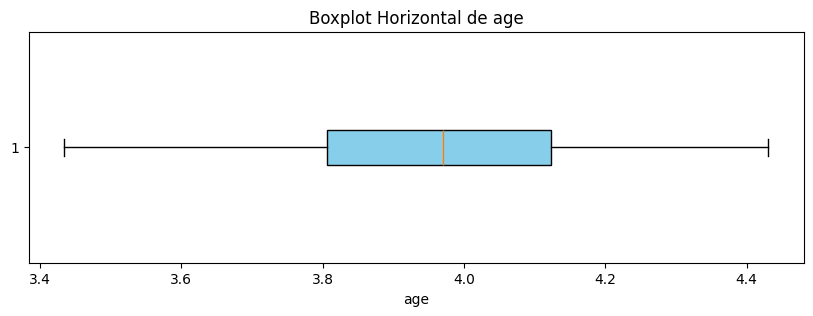

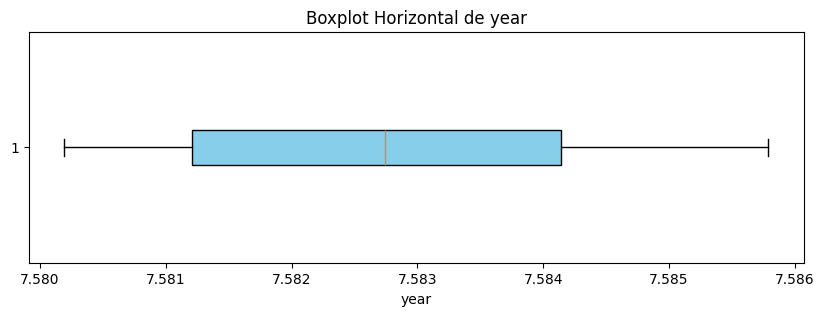

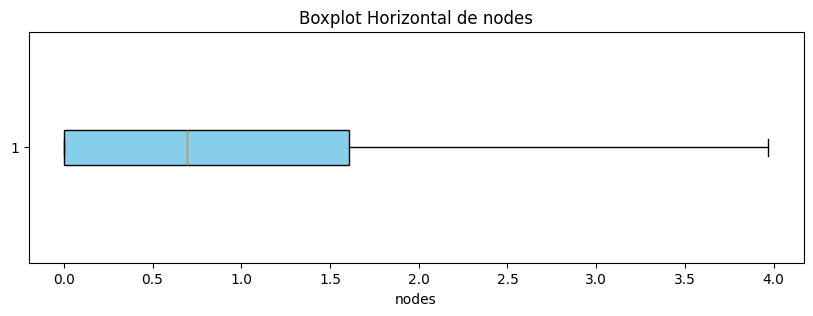

In [37]:
print_box("Boxplots Horizontales de Variables Numéricas")

# Defino las columnas numéricas que quiero revisar
columnas_numericas = ['age', 'year', 'nodes']

# Recorro cada columna y dibujo un boxplot horizontal
for col in columnas_numericas:
    plt.figure(figsize=(10,3))  # Hago la gráfica más ancha que alta para resaltar el modo horizontal

    # Creo el boxplot en horizontal. Uso patch_artist=True para poder darle color al cuadro
    plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor='#87CEEB'))
    plt.title(f"Boxplot Horizontal de {col}")
    plt.xlabel(col)
    plt.show()

## 4.5 Matriz de correlación y mapa de calor.

                         Matriz de Correlación y Mapa de Calor                         


Matriz de correlación:

            age      year     nodes
age    1.000000  0.090982 -0.085472
year   0.090982  1.000000 -0.017147
nodes -0.085472 -0.017147  1.000000




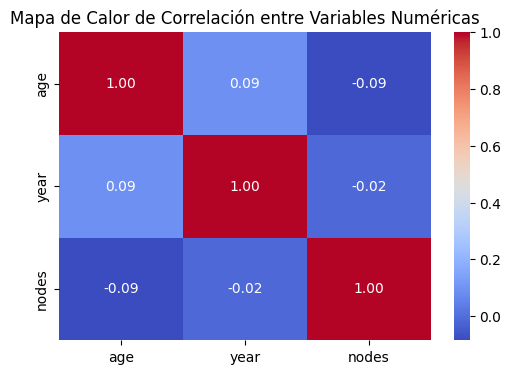

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

print_box("Matriz de Correlación y Mapa de Calor")

# Selecciono únicamente las columnas numéricas para calcular la correlación
df_corr = df[['age', 'year', 'nodes']].corr()

# Imprimo la matriz de correlación en consola para tenerla en números
print("Matriz de correlación:\n")
print(df_corr)

print("\n")
# Creo una figura y le doy un tamaño más grande para que el heatmap sea legible
plt.figure(figsize=(6,4))

# Uso seaborn.heatmap para crear el mapa de calor
#   - annot=True: muestro los valores de correlación en cada celda
#   - cmap="coolwarm": aplico un gradiente de colores para distinguir mejor positivo/negativo
#   - fmt=".2f": limito los decimales a 2 para que no se vea saturado
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")

# Agrego título para mayor claridad
plt.title("Mapa de Calor de Correlación entre Variables Numéricas")

# Muestro la gráfica en pantalla
plt.show()


## 4.6 Pairplot para visualizar relaciones entre variables numéricas.

                         Pairplot de Variables Numéricas                         




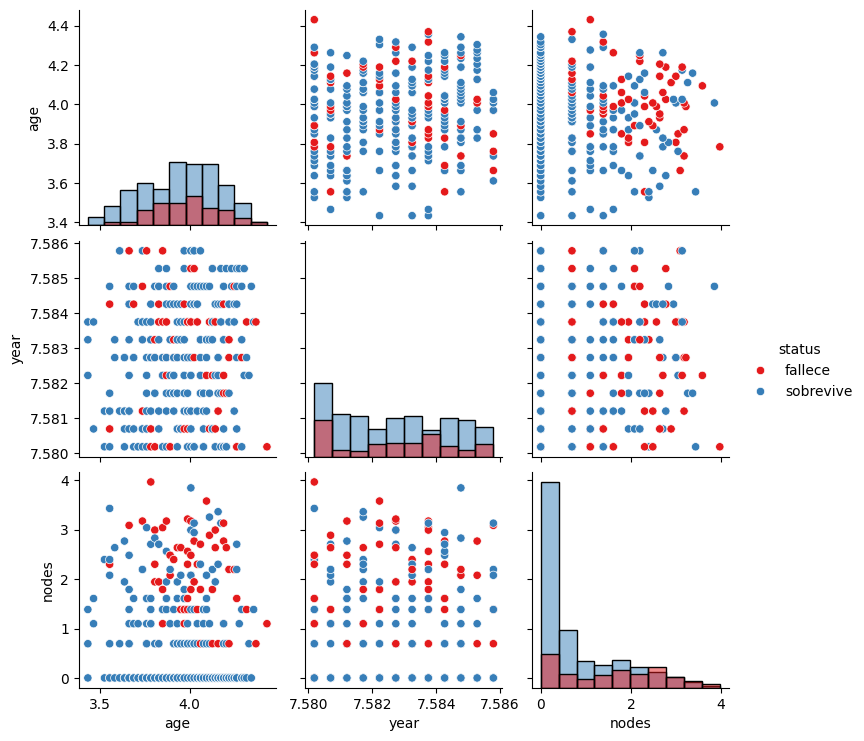

In [39]:
print_box("Pairplot de Variables Numéricas")

# Selecciono las columnas numéricas que quiero analizar
columnas_numericas = ['age', 'year', 'nodes']

# Genero el pairplot. Aquí incluyo 'status' como hue para colorear según supervivencia
#   - hue="status": me permite diferenciar los puntos por categoría (sobrevive/fallece)
#   - palette="Set1": uso una paleta de colores llamativa para distinguir las clases
#   - diag_kind="hist": en la diagonal muestro histogramas en lugar de densidades
sns.pairplot(df[columnas_numericas + ['status']], hue="status", palette="Set1", diag_kind="hist")
plt.show()

## 4.7 Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.

                         Pruebas de Normalidad y QQplots                         


                         Variable: age                         


Shapiro-Wilk → Estadístico=0.9857, p-valor=0.0040 → No_Normalidad
Anderson-Darling → Estadístico=1.0733, Crítico(5%)=0.7770 → No_Normalidad
Kolmogorov-Smirnov → Estadístico=0.0598, p-valor=0.2154 → Normalidad


<Figure size 500x500 with 0 Axes>

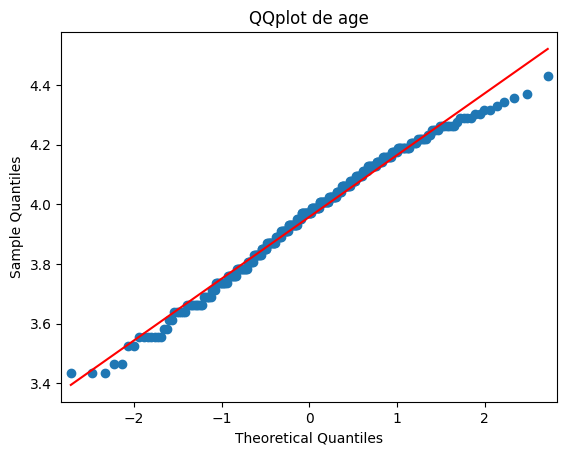

                         Variable: year                         


Shapiro-Wilk → Estadístico=0.9468, p-valor=0.0000 → No_Normalidad
Anderson-Darling → Estadístico=4.3157, Crítico(5%)=0.7770 → No_Normalidad
Kolmogorov-Smirnov → Estadístico=0.1078, p-valor=0.0015 → No_Normalidad


<Figure size 500x500 with 0 Axes>

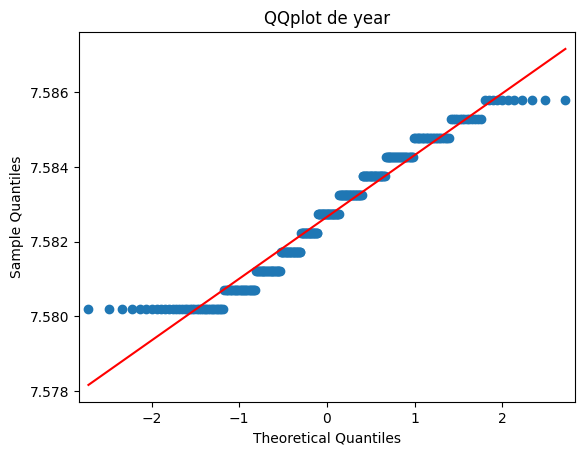

                         Variable: nodes                         


Shapiro-Wilk → Estadístico=0.8320, p-valor=0.0000 → No_Normalidad
Anderson-Darling → Estadístico=19.6013, Crítico(5%)=0.7770 → No_Normalidad
Kolmogorov-Smirnov → Estadístico=0.2591, p-valor=0.0000 → No_Normalidad


<Figure size 500x500 with 0 Axes>

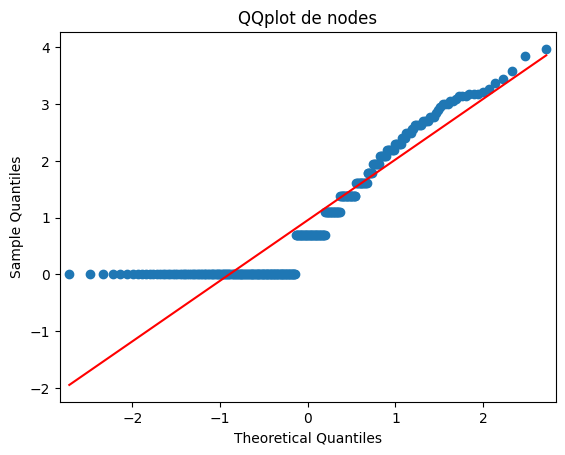

                         Resumen final de Pruebas de Normalidad                         


Variable    Shapiro_p Shapiro_Resultado  Anderson_stat  Anderson_crit_5% Anderson_Resultado         KS_p  KS_Resultado
     age 3.972334e-03     No_Normalidad       1.073349             0.777      No_Normalidad 2.153605e-01    Normalidad
    year 4.556145e-09     No_Normalidad       4.315716             0.777      No_Normalidad 1.504117e-03 No_Normalidad
   nodes 1.496666e-17     No_Normalidad      19.601319             0.777      No_Normalidad 1.309763e-18 No_Normalidad


In [40]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

print_box("Pruebas de Normalidad y QQplots")

# Selecciono las columnas numéricas
columnas_numericas = ['age', 'year', 'nodes']

# Creo un diccionario para guardar resultados
resultados = {
    'Variable': [],
    'Shapiro_p': [],
    'Shapiro_Resultado': [],
    'Anderson_stat': [],
    'Anderson_crit_5%': [],
    'Anderson_Resultado': [],
    'KS_p': [],
    'KS_Resultado': []
}

# Recorro cada columna y aplico las pruebas
for col in columnas_numericas:
    print_box(f"Variable: {col}")

    # Extraigo la serie
    datos = df[col]

    # --- Shapiro-Wilk ---
    shapiro_stat, shapiro_p = stats.shapiro(datos)
    shapiro_res = "Normalidad" if shapiro_p > 0.05 else "No_Normalidad"
    print(f"Shapiro-Wilk → Estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f} → {shapiro_res}")

    # --- Anderson-Darling ---
    anderson_result = stats.anderson(datos)
    critico_5 = anderson_result.critical_values[2]  # valor crítico al 5%
    anderson_res = "Normalidad" if anderson_result.statistic < critico_5 else "No_Normalidad"
    print(f"Anderson-Darling → Estadístico={anderson_result.statistic:.4f}, Crítico(5%)={critico_5:.4f} → {anderson_res}")

    # --- Kolmogorov-Smirnov ---
    ks_stat, ks_p = stats.kstest(
        (datos - datos.mean()) / datos.std(ddof=0), 'norm'
    )
    ks_res = "Normalidad" if ks_p > 0.05 else "No_Normalidad"
    print(f"Kolmogorov-Smirnov → Estadístico={ks_stat:.4f}, p-valor={ks_p:.4f} → {ks_res}")

    # --- QQplot ---
    plt.figure(figsize=(5,5))
    sm.qqplot(datos, line='s')
    plt.title(f"QQplot de {col}")
    plt.show()

    # Guardo resultados en el diccionario
    resultados['Variable'].append(col)
    resultados['Shapiro_p'].append(shapiro_p)
    resultados['Shapiro_Resultado'].append(shapiro_res)
    resultados['Anderson_stat'].append(anderson_result.statistic)
    resultados['Anderson_crit_5%'].append(critico_5)
    resultados['Anderson_Resultado'].append(anderson_res)
    resultados['KS_p'].append(ks_p)
    resultados['KS_Resultado'].append(ks_res)

# ===============================================
# RESUMEN DE RESULTADOS
# ===============================================
print_box("Resumen final de Pruebas de Normalidad")

df_resultados = pd.DataFrame(resultados)

print(df_resultados.head(20).to_string(index=False, line_width=1000))
